<a href="https://colab.research.google.com/github/thalyeah13/Climate-Change-Predictions/blob/main/Climate_Change_Predictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Analisis dan Prediksi Pola Perubahan Iklim Global Menggunakan Algoritma Random Forest, XGBoost, dan LightGBM Berbasis Data Historis Global**

In [188]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt
import seaborn as sns

**Data Collection**

In [189]:
df = pd.read_csv("/content/climate_change.csv")

In [190]:
df.head()

,Year,Month,MEI,CO2,CH4,N2O,CFC-11,CFC-12,TSI,Aerosols,Temp
0,1983,5,2.556,345.96,1638.59,303.677,191.324,350.113,1366.1024,0.0863,0.109
1,1983,6,2.167,345.52,1633.71,303.746,192.057,351.848,1366.1208,0.0794,0.118
2,1983,7,1.741,344.15,1633.22,303.795,192.818,353.725,1366.2850,0.0731,0.137
3,1983,8,1.130,342.25,1631.35,303.839,193.602,355.633,1366.4202,0.0673,0.176
4,1983,9,0.428,340.17,1648.40,303.901,194.392,357.465,1366.2335,0.0619,0.149


**Data Processing**

In [191]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Year      308 non-null    int64  
 1   Month     308 non-null    int64  
 2   MEI       308 non-null    float64
 3   CO2       308 non-null    float64
 4   CH4       308 non-null    float64
 5   N2O       308 non-null    float64
 6   CFC-11    308 non-null    float64
 7   CFC-12    308 non-null    float64
 8   TSI       308 non-null    float64
 9   Aerosols  308 non-null    float64
 10  Temp      308 non-null    float64
dtypes: float64(9), int64(2)
memory usage: 26.6 KB


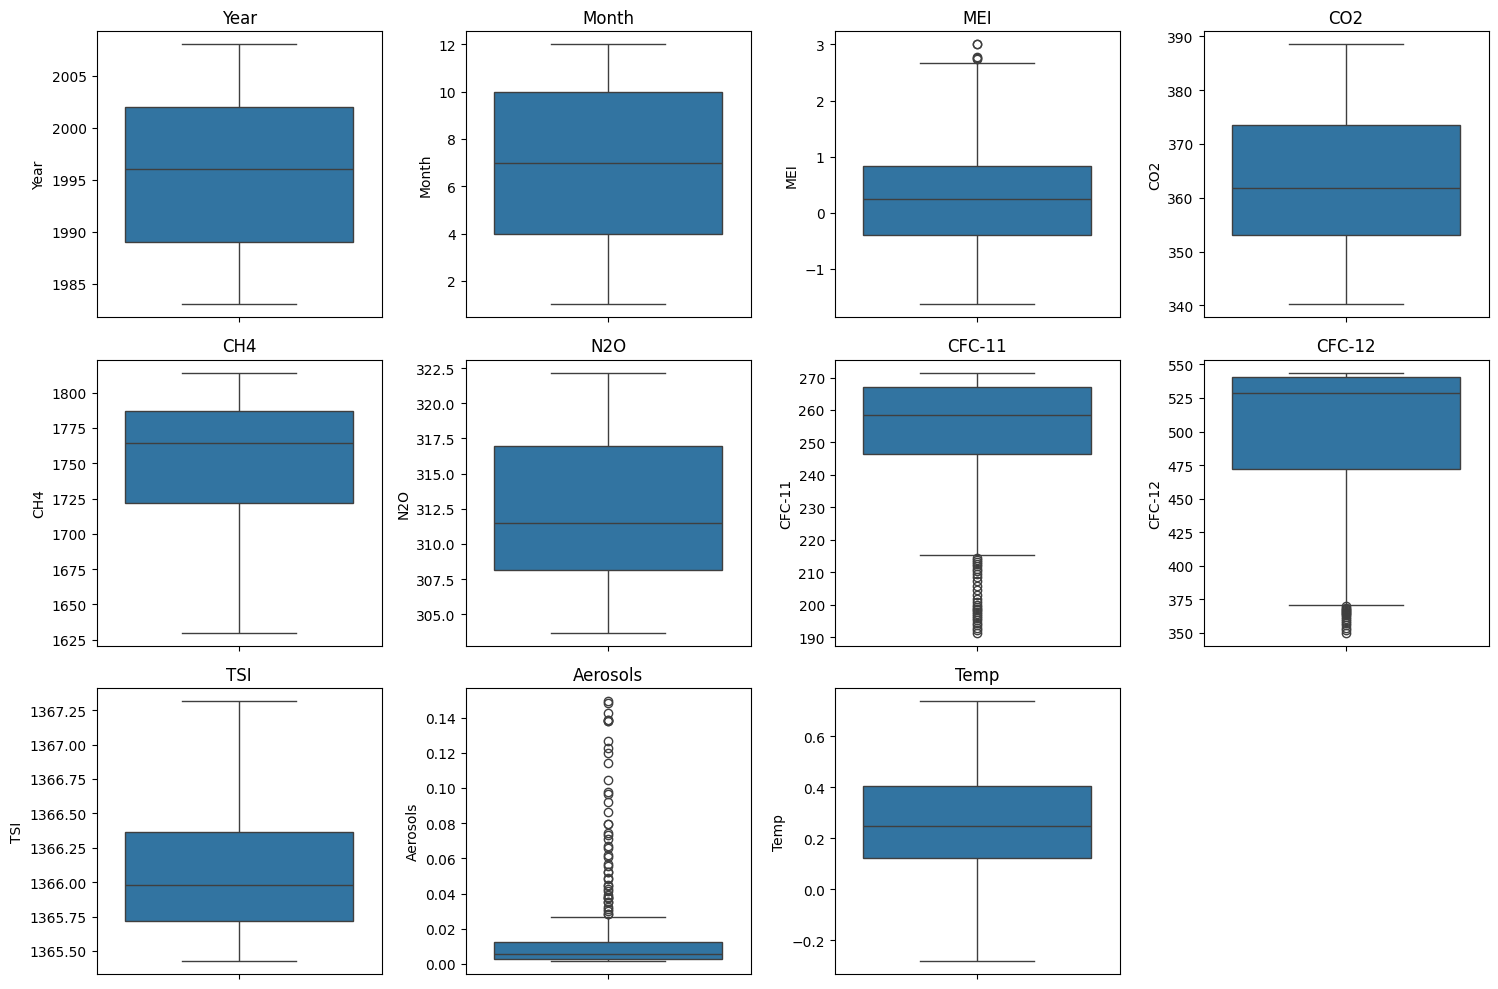

In [192]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, column in enumerate(numerical_cols):
    plt.subplot(3, 4, i + 1)
    sns.boxplot(y=df[column])
    plt.title(column)
plt.tight_layout()
plt.show()

Outliers capped for all numerical columns. Displaying updated boxplots:


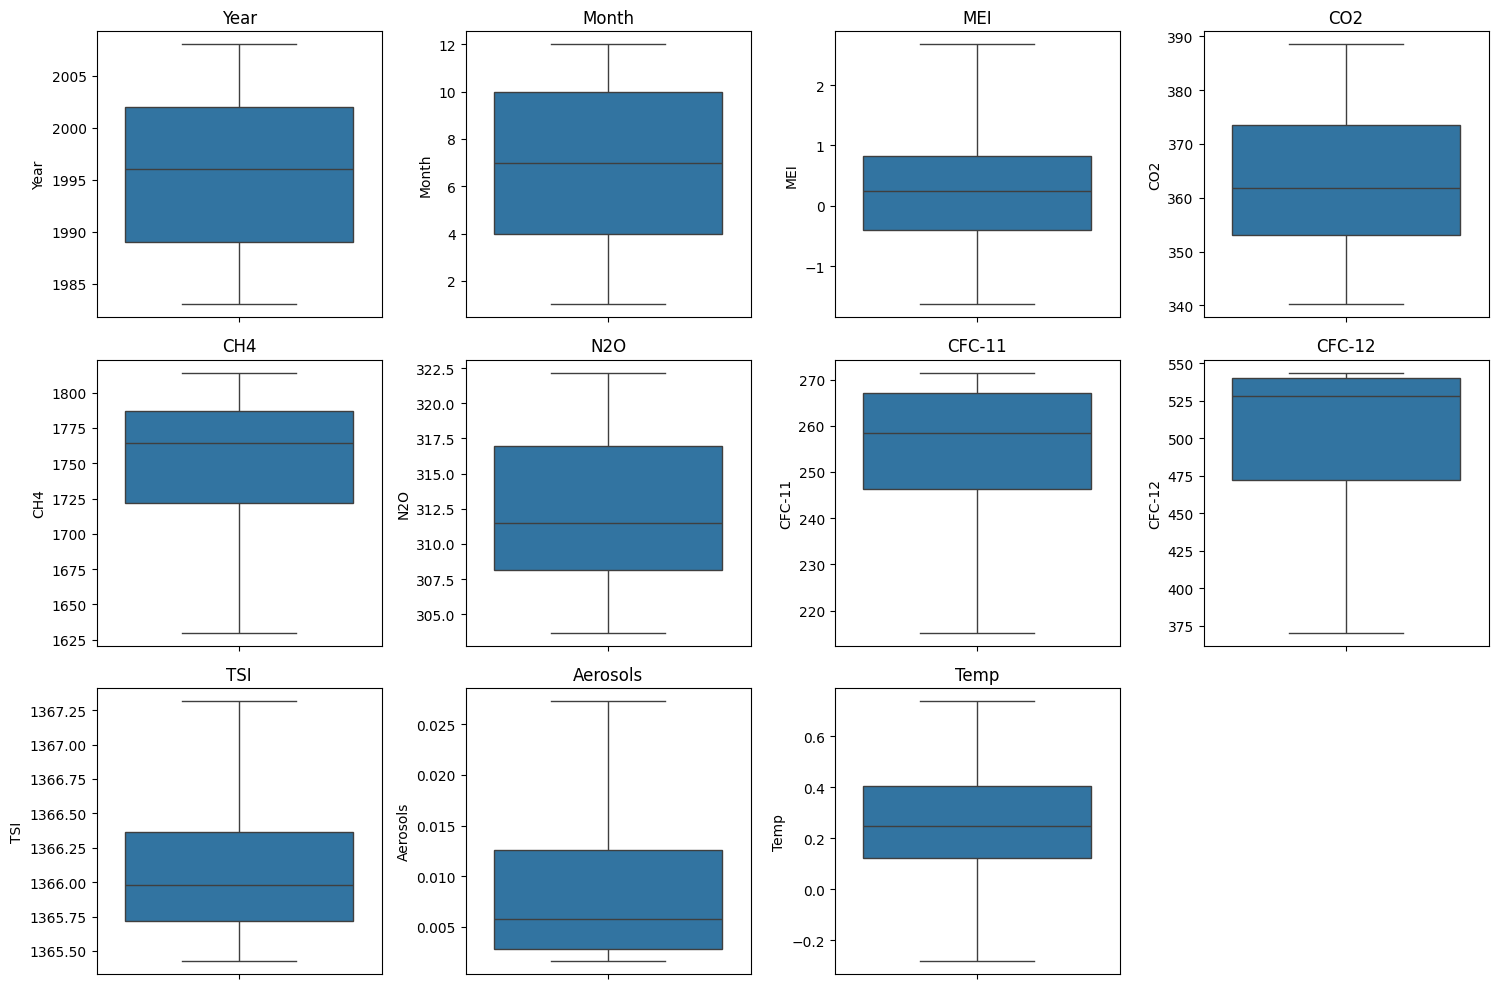

In [193]:
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    return df

for col in numerical_cols:
    df = cap_outliers_iqr(df, col)

print("Outliers capped for all numerical columns. Displaying updated boxplots:")

plt.figure(figsize=(15, 10))
for i, column in enumerate(numerical_cols):
    plt.subplot(3, 4, i + 1)
    sns.boxplot(y=df[column])
    plt.title(column)
plt.tight_layout()
plt.show()

**Exploratory Data Analysis (EDA)**

In [194]:
df.describe()

,Year,Month,MEI,CO2,CH4,N2O,CFC-11,CFC-12,TSI,Aerosols,Temp
count,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000
mean,1995.662338,6.551948,0.272600,363.226753,1749.824513,312.391834,253.172147,497.995320,1366.070759,0.009538,0.256776
std,7.423197,3.447214,0.929889,12.647125,46.051678,5.225131,17.292965,56.723717,0.399610,0.008783,0.179090
min,1983.000000,1.000000,-1.635000,340.170000,1629.890000,303.677000,215.192250,370.240500,1365.426100,0.001600,-0.282000
25%,1989.000000,4.000000,-0.398750,353.020000,1722.182500,308.111500,246.295500,472.410750,1365.717050,0.002800,0.121750
50%,1996.000000,7.000000,0.237500,361.735000,1764.040000,311.507000,258.344000,528.356000,1365.980900,0.005750,0.248000
75%,2002.000000,10.000000,0.830500,373.455000,1786.885000,316.979000,267.031000,540.524250,1366.363250,0.012600,0.407250
max,2008.000000,12.000000,2.674375,388.500000,1814.180000,322.182000,271.494000,543.813000,1367.316200,0.027300,0.739000


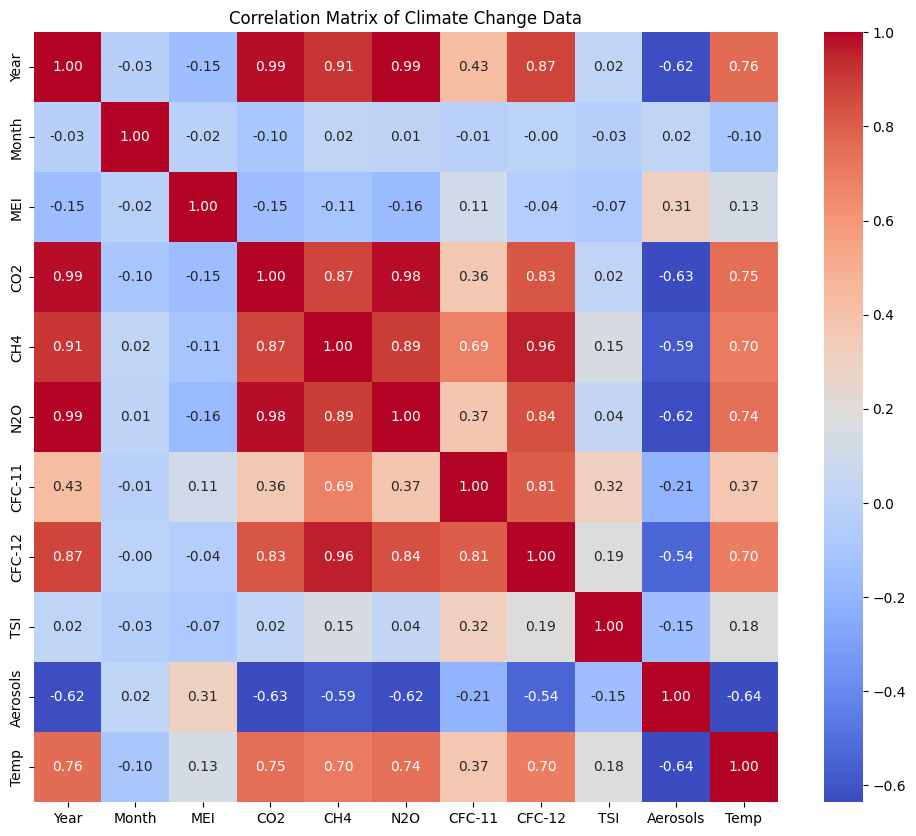

In [195]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Climate Change Data')
plt.show()

In [196]:
X = df.drop(columns=['Temp'])
y = df['Temp']

In [197]:
splits = {
    "70:30": 0.3,
    "80:20": 0.2,
    "90:10": 0.1
}

**Model Selection**

In [198]:
rf_param = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None],
    'min_samples_split':[2,5]
}

In [199]:
xgb_param = {
    'n_estimators':[100,200],
    'learning_rate':[0.01,0.1],
    'max_depth':[3,6]
}

In [200]:
lgbm_param = {
    'n_estimators':[100,200],
    'learning_rate':[0.01,0.1],
    'max_depth':[5,10]
}

In [201]:
def evaluate_model(y_test, y_pred):

    mae = mean_absolute_error(y_test,y_pred)
    mse = mean_squared_error(y_test,y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test,y_pred)

    return mae,mse,rmse,r2

**Training Model**

In [202]:
results = []

best_fitted_models = {}

models = {
    "Random Forest": (RandomForestRegressor(random_state=42), rf_param),
    "XGBoost": (XGBRegressor(random_state=42, verbosity=0), xgb_param),
    "LightGBM": (LGBMRegressor(random_state=42), lgbm_param)
}

for split_name, test_size in splits.items():

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    for name, (model, param) in models.items():

        grid = GridSearchCV(
            model,
            param,
            cv=5,
            scoring='r2',
            n_jobs=-1
        )

        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_

        best_fitted_models[f"{name}_{split_name}"] = best_model

        y_pred = best_model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)

        results.append({
            "Model": name,
            "Split": split_name,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R2": r2
        })

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000153 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 586
[LightGBM] [Info] Number of data points in the train set: 215, number of used features: 10
[LightGBM] [Info] Start training from score 0.260688
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

**Evaluation**

In [203]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["Split", "R2"],
    ascending=[True, False]
).reset_index(drop=True)

results_df

,Model,Split,MAE,MSE,RMSE,R2
0,Random Forest,70:30,0.062299,0.006068,0.077898,0.824728
1,LightGBM,70:30,0.062120,0.006538,0.080858,0.811154
2,XGBoost,70:30,0.064177,0.006775,0.082311,0.804308
3,Random Forest,80:20,0.056339,0.005330,0.073009,0.834903
4,XGBoost,80:20,0.058943,0.005703,0.075516,0.823373
5,LightGBM,80:20,0.058766,0.005776,0.076000,0.821101
6,Random Forest,90:10,0.043425,0.003159,0.056208,0.887116
7,XGBoost,90:10,0.048899,0.003822,0.061819,0.863453
8,LightGBM,90:10,0.050315,0.004304,0.065606,0.846210


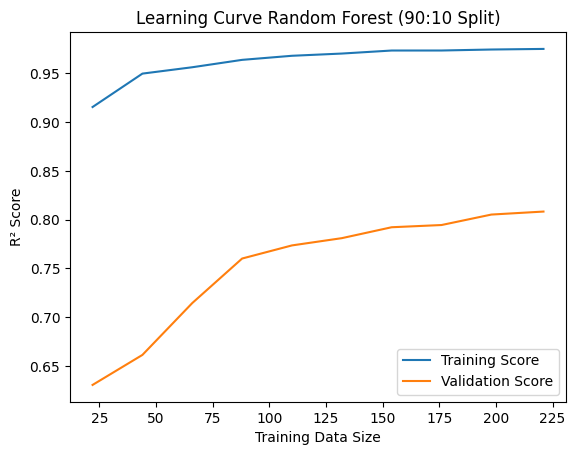

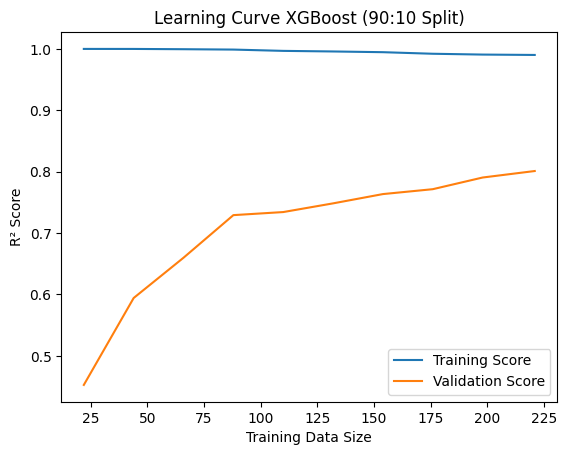

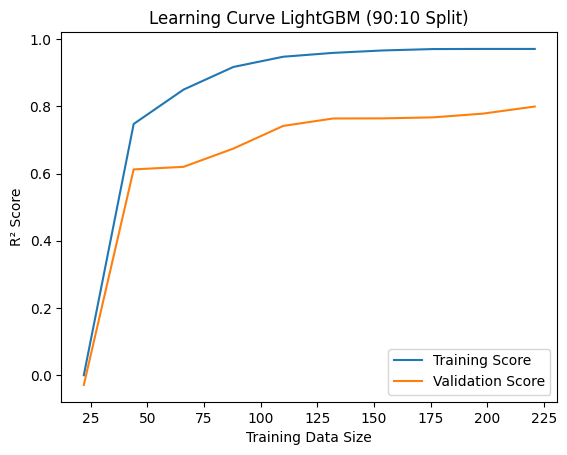

In [204]:
def plot_learning_curve(model, X, y, title):

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)

    plt.figure()
    plt.plot(train_sizes, train_mean, label="Training Score")
    plt.plot(train_sizes, val_mean, label="Validation Score")

    plt.title(title)
    plt.xlabel("Training Data Size")
    plt.ylabel("R² Score")
    plt.legend()
    plt.show()

plot_learning_curve(best_fitted_models["Random Forest_90:10"], X_train, y_train, "Learning Curve Random Forest (90:10 Split)")
plot_learning_curve(best_fitted_models["XGBoost_90:10"], X_train, y_train, "Learning Curve XGBoost (90:10 Split)")
plot_learning_curve(best_fitted_models["LightGBM_90:10"], X_train, y_train, "Learning Curve LightGBM (90:10 Split)")

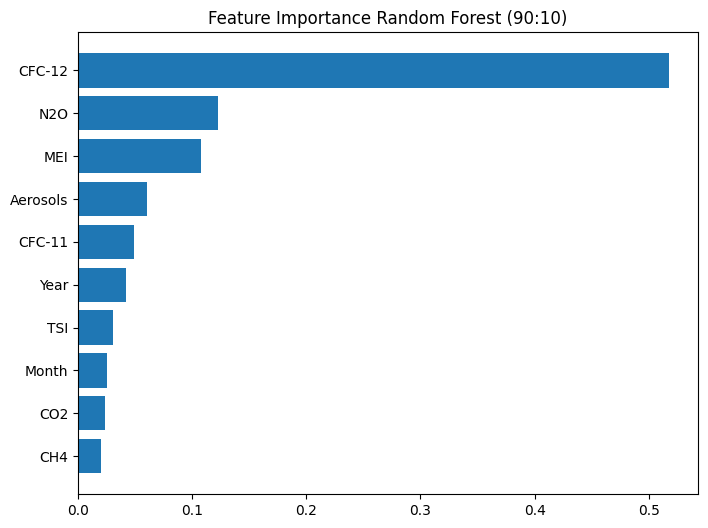

In [205]:
def plot_feature_importance(model, feature_names, title):

    importance = model.feature_importances_

    sorted_idx = np.argsort(importance)

    plt.figure(figsize=(8,6))
    plt.barh(range(len(sorted_idx)), importance[sorted_idx])
    plt.yticks(range(len(sorted_idx)), np.array(feature_names)[sorted_idx])
    plt.title(title)
    plt.show()


plot_feature_importance(
    best_fitted_models["Random Forest_90:10"],
    X.columns,
    "Feature Importance Random Forest (90:10)"
)

**Model Inference**

In [206]:
new_data_input = {}
print("Please enter values for the following features:")
for col in X.columns:
    while True:
        try:
            value = float(input(f"Enter value for {col}: "))
            new_data_input[col] = [value]
            break
        except ValueError:
            print("Invalid input. Please enter a numerical value.")

new_df = pd.DataFrame(new_data_input)
print("\nNew DataFrame for prediction:")
display(new_df)

best_rf_model_90_10 = best_fitted_models["Random Forest_90:10"]

prediction = best_rf_model_90_10.predict(new_df)

print(f"Predicted Temperature: {prediction[0]:.3f}")

Please enter values for the following features:
Enter value for Year: 1983
Enter value for Month: 5
Enter value for MEI: 2.556
Enter value for CO2: 345.96
Enter value for CH4: 1638.59
Enter value for N2O: 303.677
Enter value for CFC-11: 191.324
Enter value for CFC-12: 350.113
Enter value for TSI: 1366.1024
Enter value for Aerosols: 0.0863

New DataFrame for prediction:


,Year,Month,MEI,CO2,CH4,N2O,CFC-11,CFC-12,TSI,Aerosols
0,1983.0,5.0,2.556,345.96,1638.59,303.677,191.324,350.113,1366.1024,0.0863


Predicted Temperature: 0.117
